In [1]:
import sys
from pathlib import Path
# sys.path.insert(0,str(Path(r'C:\Users\ku51015\CHMURA\mystuff\Graph-Vizualisation-Rating-Metric-randoms (1)').resolve()))
sys.path.insert(0,str(Path(r'C:\Users\Kinga\Desktop\MAGISTERKA\Graph-Vizualisation-Rating-Metric-3').resolve()))

from graph_generating_script import *
from graph_metric_script import *
import matplotlib.pyplot as plt
import igraph as ig
import numpy as np
import pickle
import os
# List of layouts
np.random.seed(212)


# Reading lambdas from corr

In [2]:
BA_corr = pd.read_csv(r'lambdas\BA_corrs.csv')
BA_corr.head()

,score,node_distribution,node_distribution_raw,distance_to_borderlines,distance_to_borderlines_raw,edge_length_sum,edge_length_sum_raw,edge_node_distance_contribution,edge_node_distance_contribution_raw,count_edge_crossings,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry,category
0,1.0,-0.438908,-0.295487,0.493136,0.513931,0.188714,0.152569,-0.0563,-0.230325,-0.065893,-0.138188,0.295741,0.054358,-0.514301,BA


In [3]:
BA_corr.iloc[:, :-1] = BA_corr.iloc[:, :-1].applymap(lambda x: 0 if abs(x) < 0.2 else x)
BA_corr.head()


C:\Users\Kinga\AppData\Local\Temp\ipykernel_17024\2089714033.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  BA_corr.iloc[:, :-1] = BA_corr.iloc[:, :-1].applymap(lambda x: 0 if abs(x) < 0.2 else x)


,score,node_distribution,node_distribution_raw,distance_to_borderlines,distance_to_borderlines_raw,edge_length_sum,edge_length_sum_raw,edge_node_distance_contribution,edge_node_distance_contribution_raw,count_edge_crossings,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry,category
0,1.0,-0.438908,-0.295487,0.493136,0.513931,0.0,0.0,0.0,-0.230325,0.0,0.0,0.295741,0.0,-0.514301,BA


In [4]:
# From abservation above
BA_corr.drop(columns=['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution',
                      'count_edge_crossings_raw'], inplace=True, axis=1)

BA_corr.head()


,score,node_distribution,distance_to_borderlines_raw,edge_length_sum,edge_node_distance_contribution_raw,count_edge_crossings,communities_closeness,sum_of_angles,symmetry,category
0,1.0,-0.438908,0.513931,0.0,-0.230325,0.0,0.295741,0.0,-0.514301,BA


In [10]:
def calculate_metric(lambdas, G, posdf, print_raw=False):

    raw_values = {
        'node_distribution' : node_distribution(posdf),
        'distance_to_borderlines_raw' : distance_to_borderlines_raw(posdf),
        'edge_length_sum' : edge_length_sum(G, posdf),
        'edge_node_distance_contribution_raw' : edge_node_distance_contribution_raw(G, posdf)[0],
        'count_edge_crossings' : count_edge_crossings(G, posdf),
        'communities_closeness' : intra_cluster_distance(G, posdf)['overall_sum'],
        'sum_of_angles' : sum_of_angles(G, posdf),
        'symmetry' : measure_graph_symmetry(G, posdf)
    }
    if print_raw:
        print(raw_values)
    values = raw_values.copy()

    i=0
    score=0
    for col in lambdas.columns:
        if col not in ['score', 'category']:

            component = lambdas[col][0] * values[col]
            values[col] = component
            # print(f'{col} : {round(component, 2)}')
            score += component
            i+=1
        
    # score = -0.42*node_distribution_raw(posdf) +0.34*edge_length_sum(G, posdf) + 0.39*measure_communities_closeness(G, posdf) -0.47*measure_graph_symmetry(G, posdf)
    # score = -0.42*rescaled_values[0] +0.34*rescaled_values[1] + 0.39*rescaled_values[2] -0.47*rescaled_values[3]

    print(f'SCORE: {round(score, 2)}')
    return (score, values)

# Tests

In [6]:
with open(r'tests\graph_objects\graph_ER_1_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_ER_1_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_ER_1_kamada_kawai.csv')


In [7]:
# nx.draw(G, pos=posdf)
# calculate_metric(BA_corr, G, posdf)

In [8]:
# posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_ER_1_kamada_kawai.csv')
# calculate_metric(BA_corr, G, posdf_worse)

SCORE: 47.6


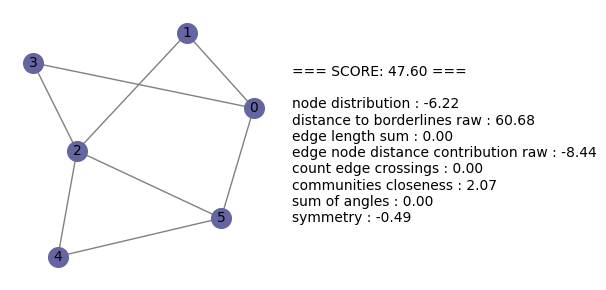

SCORE: -59.0


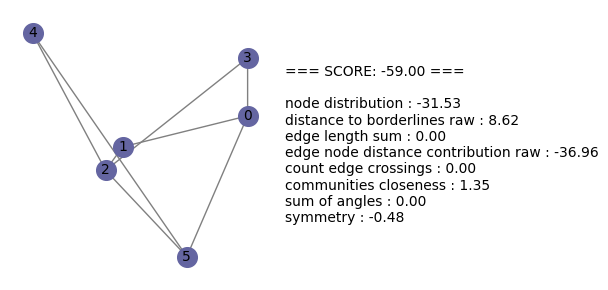

In [11]:
def show_graph_stats(lambdas, G, posdf, print_raw=False):
    (score, values) = calculate_metric(lambdas, G, posdf, print_raw)

    pos = {i: (row['X'], row['Y']) for i, row in posdf.iterrows()}

    metrics_text = f"=== SCORE: {score:.2f} === \n \n"
    metrics_text += "\n".join([f"{key.replace('_', ' ')} : {value:.2f}" for key, value in values.items()])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), gridspec_kw={'width_ratios': [3, 1]})


#TODO change this to a prettier color
    nx.draw(G, pos=pos, with_labels=True, edge_color='gray',node_color='#6465A1', node_size=200, font_size=10, ax=ax1)
    ax2.text(0, .5, metrics_text, fontsize=10, ha='left', va='center', transform=ax2.transAxes)
    ax2.axis('off')  # Hide the axes

    plt.tight_layout()
    plt.show()
# nx.draw(G, pos=pos)

show_graph_stats(BA_corr, G, posdf)
show_graph_stats(BA_corr, G, posdf_worse)

# test 2

SCORE: 29.87


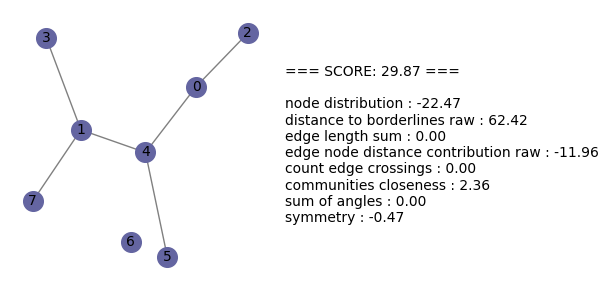

SCORE: 3.14


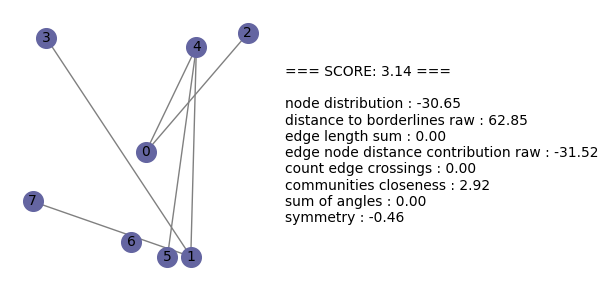

In [12]:
with open(r'tests\graph_objects\graph_ER_2_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_ER_2_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_ER_2_kamada_kawai.csv')
show_graph_stats(BA_corr, G, posdf)
show_graph_stats(BA_corr, G, posdf_worse)


# BA 

### test 3

SCORE: 41.32


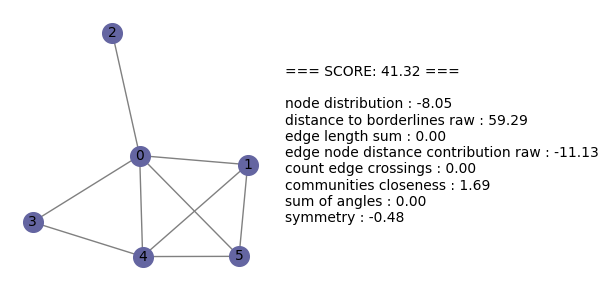

SCORE: 43.32


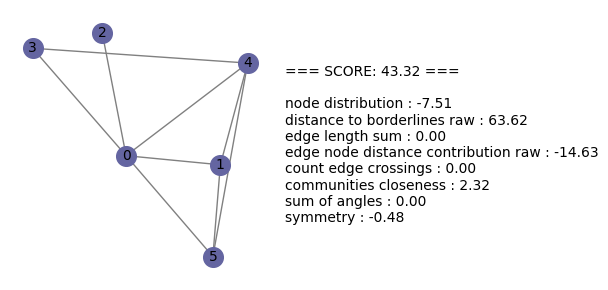

In [13]:
with open(r'tests\graph_objects\graph_BA_3_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_BA_3_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_BA_3_kamada_kawai.csv')
show_graph_stats(BA_corr, G, posdf)
show_graph_stats(BA_corr, G, posdf_worse)


### test 4


SCORE: 133.15


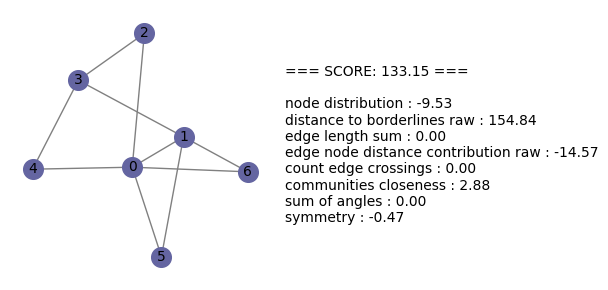

SCORE: -1.78


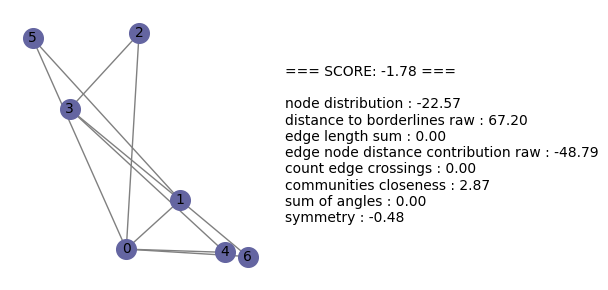

In [14]:
with open(r'tests\graph_objects\graph_BA_4_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_BA_4_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_BA_4_kamada_kawai.csv')
show_graph_stats(BA_corr, G, posdf)
show_graph_stats(BA_corr, G, posdf_worse)


# WS

SCORE: 62.94


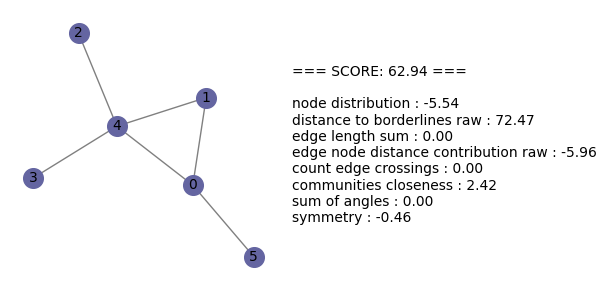

SCORE: 47.2


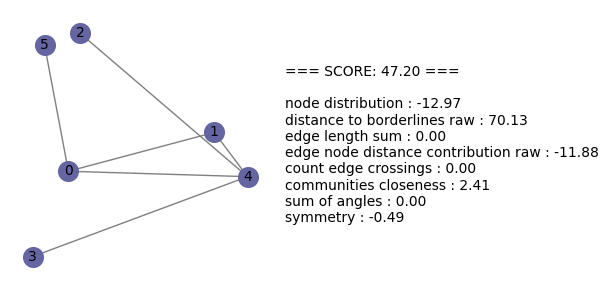

In [15]:
with open(r'tests\graph_objects\graph_WS_5_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_WS_5_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_WS_5_kamada_kawai.csv')
show_graph_stats(BA_corr, G, posdf)
show_graph_stats(BA_corr, G, posdf_worse)


{'node_distribution': np.float64(129.2904524109153), 'distance_to_borderlines_raw': np.float64(123.457), 'edge_length_sum': 1.4769971137850322, 'edge_node_distance_contribution_raw': np.float64(145.21807995121046), 'count_edge_crossings': 0, 'communities_closeness': np.float64(9.069027526844039), 'sum_of_angles': np.float64(6.01092679340088), 'symmetry': np.float64(0.9428648662067118)}
SCORE: -24.55


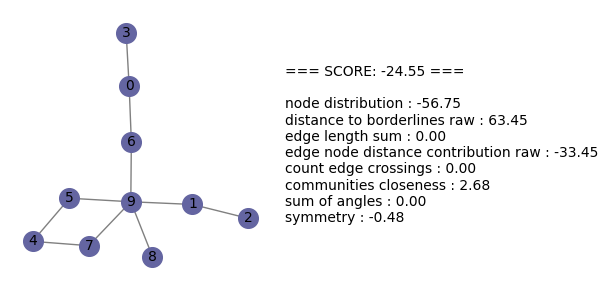

{'node_distribution': np.float64(102.71611619579996), 'distance_to_borderlines_raw': np.float64(125.671), 'edge_length_sum': 5.939984225273028, 'edge_node_distance_contribution_raw': np.float64(171.31595986748925), 'count_edge_crossings': 9, 'communities_closeness': np.float64(9.520705274148737), 'sum_of_angles': np.float64(5.5607991921122295), 'symmetry': np.float64(0.9385999270856424)}
SCORE: -17.62


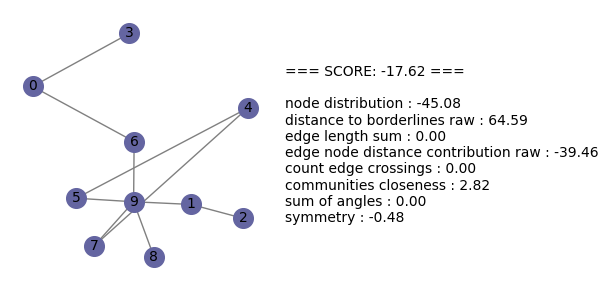

In [16]:
with open(r'tests\graph_objects\graph_WS_6_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_WS_6_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_WS_6_kamada_kawai.csv')
show_graph_stats(BA_corr, G, posdf, True)
show_graph_stats(BA_corr, G, posdf_worse, True)


# RGG

SCORE: 74.98


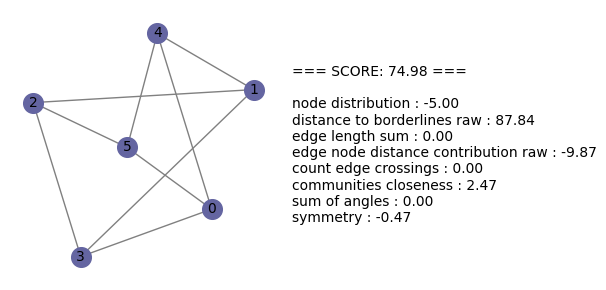

SCORE: 69.44


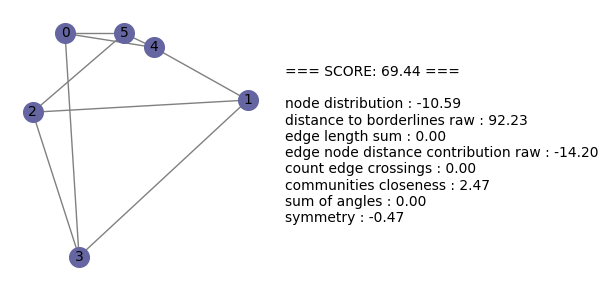

In [17]:
with open(r'tests\graph_objects\graph_RGG_7_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_RGG_7_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_RGG_7_kamada_kawai.csv')
show_graph_stats(BA_corr, G, posdf)
show_graph_stats(BA_corr, G, posdf_worse)


SCORE: 51.66


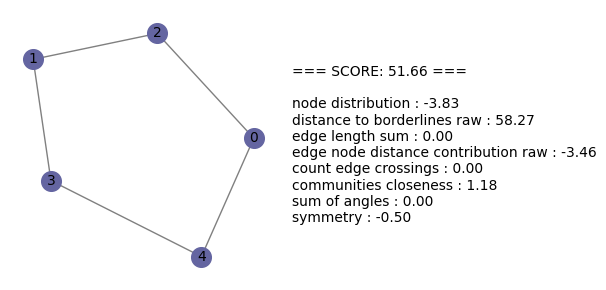

SCORE: 51.27


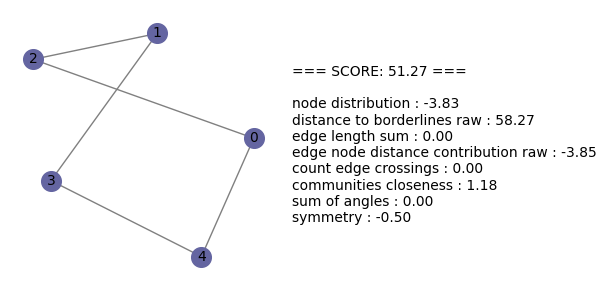

In [18]:
with open(r'tests\graph_objects\graph_RGG_8_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_RGG_8_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_RGG_8_kamada_kawai.csv')
show_graph_stats(BA_corr, G, posdf)
show_graph_stats(BA_corr, G, posdf_worse)
